In [1]:
from pathlib import Path
import json

import geopandas as gpd
import pandas as pd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
project_root = Path.cwd().parent

raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"

In [3]:
graph_path = raw_dir / "osm_walk_network.graphml"

G_walk = ox.load_graphml(graph_path)

print("Nodes:", len(G_walk.nodes))
print("Edges:", len(G_walk.edges))
print("Graph CRS:", G_walk.graph["crs"])

Nodes: 5451
Edges: 13330
Graph CRS: epsg:4326


In [4]:
def load_geojson(path):
    with open(path, "r") as f:
        data = json.load(f)

    return gpd.GeoDataFrame.from_features(
        data["features"],
        crs="EPSG:4326"
    )

In [5]:
peninsula = load_geojson(
    processed_dir / "long_beach_peninsula_boundary.geojson"
)

hazard = load_geojson(
    processed_dir / "long_beach_tsunami_hazard.geojson"
)

destinations = load_geojson(
    processed_dir / "long_beach_evacuation_destinations.geojson"
)

In [6]:
print("Destinations:", len(destinations))
print(destinations.crs)

Destinations: 7
EPSG:4326


In [7]:
print("Graph CRS:", G_walk.graph["crs"])
print("Destination CRS:", destinations.crs)

Graph CRS: epsg:4326
Destination CRS: EPSG:4326


In [8]:
destination_nodes, snap_distances = ox.distance.nearest_nodes(
    G_walk,
    X=destinations.geometry.x,
    Y=destinations.geometry.y,
    return_dist=True
)

In [9]:
destinations["network_node"] = destination_nodes
destinations["snap_distance_m"] = snap_distances

In [10]:
destinations[
    [
        "SITE_NAME",
        "ELEVATION_FT",
        "network_node",
        "snap_distance_m"
    ]
]

,SITE_NAME,ELEVATION_FT,network_node,snap_distance_m
0,Long Beach Assembly Area,76,12603115846,311.682891
1,Willapa Wildlife Refuge HQ,66,12175867812,14.644221
2,School Hill,75,2746606957,1.687837
3,North Head Rd #3,119,1323188098,445.425666
4,North Head Rd #2,109,5247788800,208.801247
5,North Head Rd #1,93,5359185614,119.432392
6,China Hill,39,50159010,23.716528


In [11]:
destinations["snap_distance_m"].describe()

count      7.000000
mean     160.770112
std      169.932771
min        1.687837
25%       19.180374
50%      119.432392
75%      260.242069
max      445.425666
Name: snap_distance_m, dtype: float64

In [12]:
print(
    "Maximum snapping distance:",
    f"{destinations['snap_distance_m'].max():.1f} m"
)

Maximum snapping distance: 445.4 m


In [13]:
destinations.sort_values(
    "snap_distance_m",
    ascending=False
)[
    ["SITE_NAME", "snap_distance_m"]
]

,SITE_NAME,snap_distance_m
3,North Head Rd #3,445.425666
0,Long Beach Assembly Area,311.682891
4,North Head Rd #2,208.801247
5,North Head Rd #1,119.432392
6,China Hill,23.716528
1,Willapa Wildlife Refuge HQ,14.644221
2,School Hill,1.687837


In [14]:
nodes, edges = ox.graph_to_gdfs(G_walk)

In [15]:
destination_node_ids = destinations["network_node"].unique()

destination_network_nodes = nodes.loc[
    nodes.index.isin(destination_node_ids)
]

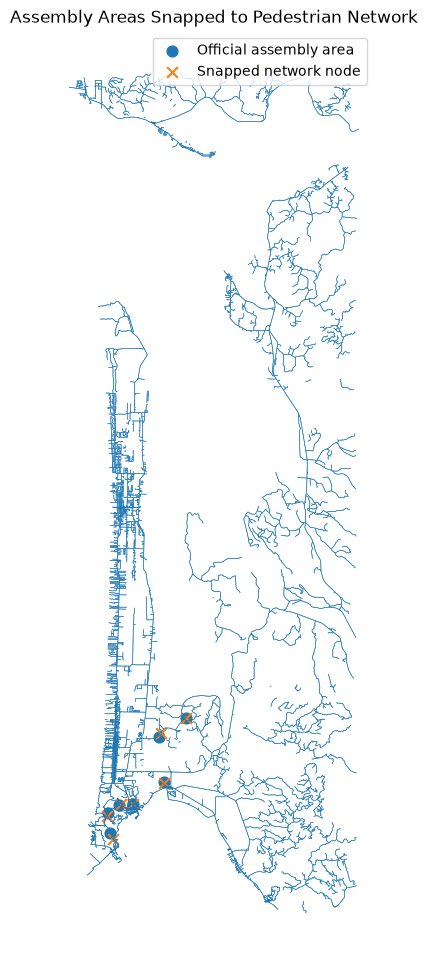

In [16]:
ax = edges.plot(
    figsize=(8, 12),
    linewidth=0.4
)

destinations.plot(
    ax=ax,
    marker="o",
    markersize=60,
    label="Official assembly area"
)

destination_network_nodes.plot(
    ax=ax,
    marker="x",
    markersize=60,
    label="Snapped network node"
)

ax.set_title("Assembly Areas Snapped to Pedestrian Network")
ax.set_axis_off()
ax.legend()

In [17]:
print(
    "Unique assembly areas:",
    len(destinations)
)

print(
    "Unique destination nodes:",
    destinations["network_node"].nunique()
)

Unique assembly areas: 7
Unique destination nodes: 7


In [18]:
components = list(
    nx.weakly_connected_components(G_walk)
)

node_to_component = {
    node: component_id
    for component_id, component in enumerate(components)
    for node in component
}

destinations["component_id"] = (
    destinations["network_node"]
    .map(node_to_component)
)

destinations[
    [
        "SITE_NAME",
        "network_node",
        "component_id",
        "snap_distance_m"
    ]
]

,SITE_NAME,network_node,component_id,snap_distance_m
0,Long Beach Assembly Area,12603115846,0,311.682891
1,Willapa Wildlife Refuge HQ,12175867812,0,14.644221
2,School Hill,2746606957,0,1.687837
3,North Head Rd #3,1323188098,0,445.425666
4,North Head Rd #2,5247788800,0,208.801247
5,North Head Rd #1,5359185614,0,119.432392
6,China Hill,50159010,0,23.716528


In [19]:
destinations["component_id"].value_counts()

component_id
0    7
Name: count, dtype: int64

In [20]:
G_proj = ox.project_graph(G_walk)

nodes_proj, edges_proj = ox.graph_to_gdfs(G_proj)

print("Projected CRS:", G_proj.graph["crs"])

Projected CRS: EPSG:32610


In [21]:
destinations_proj = destinations.to_crs(
    G_proj.graph["crs"]
)

In [22]:
nearest_edges, edge_distances = ox.distance.nearest_edges(
    G_proj,
    X=destinations_proj.geometry.x,
    Y=destinations_proj.geometry.y,
    return_dist=True
)

In [23]:
destinations["nearest_edge_distance_m"] = edge_distances

In [24]:
destinations[
    [
        "SITE_NAME",
        "snap_distance_m",
        "nearest_edge_distance_m"
    ]
].sort_values(
    "snap_distance_m",
    ascending=False
)

,SITE_NAME,snap_distance_m,nearest_edge_distance_m
3,North Head Rd #3,445.425666,7.041050
0,Long Beach Assembly Area,311.682891,40.648203
4,North Head Rd #2,208.801247,4.835059
5,North Head Rd #1,119.432392,1.878536
6,China Hill,23.716528,23.700989
1,Willapa Wildlife Refuge HQ,14.644221,14.669272
2,School Hill,1.687837,1.634508


In [25]:
destinations_proj["nearest_edge"] = list(nearest_edges)
destinations_proj["edge_distance_m"] = edge_distances

In [26]:
destinations_proj[
    [
        "SITE_NAME",
        "nearest_edge",
        "edge_distance_m"
    ]
]

,SITE_NAME,nearest_edge,edge_distance_m
0,Long Beach Assembly Area,"(50146261, 12603115846, 0)",40.648203
1,Willapa Wildlife Refuge HQ,"(12175867809, 12175867812, 0)",14.669272
2,School Hill,"(2746606957, 50148835, 0)",1.634508
3,North Head Rd #3,"(1323188098, 50045747, 0)",7.041050
4,North Head Rd #2,"(5247788799, 5247788800, 0)",4.835059
5,North Head Rd #1,"(5359185832, 50156428, 0)",1.878536
6,China Hill,"(50159010, 50158993, 0)",23.700989


In [27]:
from shapely.ops import nearest_points

In [28]:
access_points = []

for idx, destination in destinations_proj.iterrows():
    
    u, v, key = destination["nearest_edge"]
    
    edge_geom = edges_proj.loc[(u, v, key)].geometry
    
    # Find the point on the pedestrian edge closest
    # to the official assembly-area location
    _, access_point = nearest_points(
        destination.geometry,
        edge_geom
    )
    
    access_points.append(access_point)

destinations_proj["access_geometry"] = access_points

In [29]:
destinations_proj["access_distance_m"] = [
    destination.geometry.distance(access_point)
    for (_, destination), access_point
    in zip(
        destinations_proj.iterrows(),
        destinations_proj["access_geometry"]
    )
]

In [30]:
destinations_proj[
    [
        "SITE_NAME",
        "edge_distance_m",
        "access_distance_m"
    ]
]

,SITE_NAME,edge_distance_m,access_distance_m
0,Long Beach Assembly Area,40.648203,40.648203
1,Willapa Wildlife Refuge HQ,14.669272,14.669272
2,School Hill,1.634508,1.634508
3,North Head Rd #3,7.041050,7.041050
4,North Head Rd #2,4.835059,4.835059
5,North Head Rd #1,1.878536,1.878536
6,China Hill,23.700989,23.700989


In [31]:
difference = (
    destinations_proj["edge_distance_m"]
    - destinations_proj["access_distance_m"]
).abs()

print("Maximum difference:", difference.max())

Maximum difference: 2.540376797810495e-10


In [32]:
access_gdf = gpd.GeoDataFrame(
    destinations_proj[
        ["SITE_NAME", "access_distance_m"]
    ].copy(),
    geometry=destinations_proj["access_geometry"],
    crs=destinations_proj.crs
)

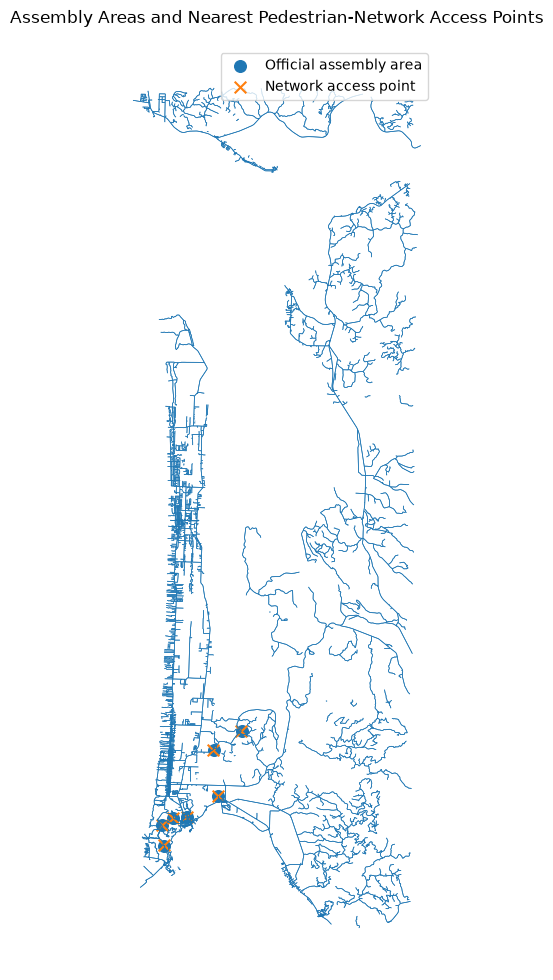

In [33]:
ax = edges_proj.plot(
    figsize=(9, 12),
    linewidth=0.5
)

destinations_proj.plot(
    ax=ax,
    marker="o",
    markersize=70,
    label="Official assembly area"
)

access_gdf.plot(
    ax=ax,
    marker="x",
    markersize=70,
    label="Network access point"
)

ax.set_title(
    "Assembly Areas and Nearest Pedestrian-Network Access Points"
)
ax.set_axis_off()
ax.legend()

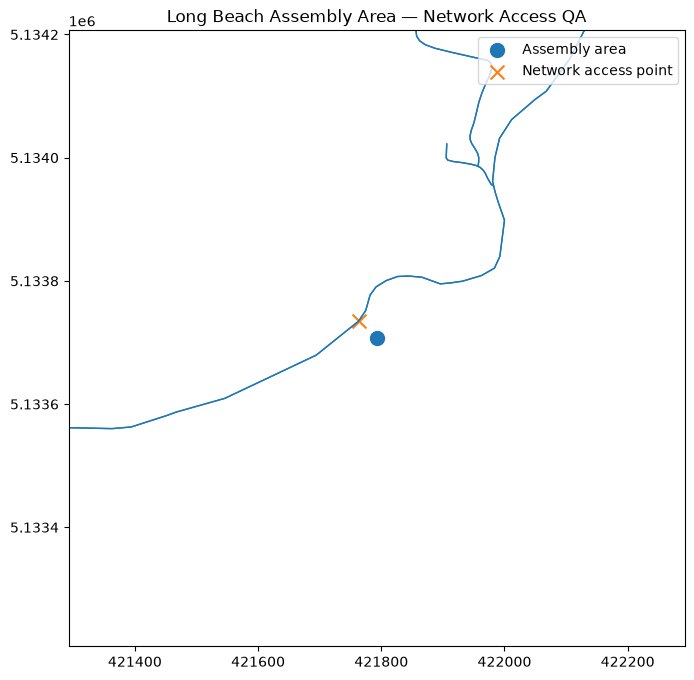

In [34]:
site_name = "Long Beach Assembly Area"

site = destinations_proj[
    destinations_proj["SITE_NAME"] == site_name
]

site_access = access_gdf[
    access_gdf["SITE_NAME"] == site_name
]

x = site.geometry.iloc[0].x
y = site.geometry.iloc[0].y

buffer_m = 500

ax = edges_proj.plot(
    figsize=(8, 8),
    linewidth=1
)

site.plot(
    ax=ax,
    marker="o",
    markersize=100,
    label="Assembly area"
)

site_access.plot(
    ax=ax,
    marker="x",
    markersize=100,
    label="Network access point"
)

ax.set_xlim(x - buffer_m, x + buffer_m)
ax.set_ylim(y - buffer_m, y + buffer_m)

ax.set_title("Long Beach Assembly Area — Network Access QA")
ax.legend()

In [35]:
import numpy as np

from shapely.geometry import Point, LineString

In [36]:
def get_edge_geometry(G, u, v, key):
    data = G.get_edge_data(u, v, key)

    if "geometry" in data:
        return data["geometry"]

    return LineString([
        (G.nodes[u]["x"], G.nodes[u]["y"]),
        (G.nodes[v]["x"], G.nodes[v]["y"])
    ])


def distance_from_start_node(G, u, v, key, point):
    data = G.get_edge_data(u, v, key)
    geom = get_edge_geometry(G, u, v, key)

    if geom.length == 0:
        return 0.0

    u_point = Point(
        G.nodes[u]["x"],
        G.nodes[u]["y"]
    )

    start_point = Point(geom.coords[0])
    end_point = Point(geom.coords[-1])

    projected_distance = geom.project(point)

    # Make sure geometry orientation agrees with u -> v
    if start_point.distance(u_point) <= end_point.distance(u_point):
        fraction = projected_distance / geom.length
    else:
        fraction = (
            geom.length - projected_distance
        ) / geom.length

    return float(data["length"]) * fraction

In [37]:
G_route = G_proj.copy()

In [38]:
super_sink = "__all_destinations__"

G_route.add_node(super_sink)

destination_terminal_to_name = {}

In [39]:
for idx, destination in destinations_proj.iterrows():

    u, v, key = destination["nearest_edge"]

    access_point = destination["access_geometry"]
    off_network_distance = destination["access_distance_m"]

    terminal = f"destination_{idx}"

    destination_terminal_to_name[terminal] = destination["SITE_NAME"]

    G_route.add_node(
        terminal,
        destination_name=destination["SITE_NAME"]
    )

    # Cost from u along the edge to the access point
    u_to_access = distance_from_start_node(
        G_route,
        u,
        v,
        key,
        access_point
    )

    G_route.add_edge(
        u,
        terminal,
        length=u_to_access + off_network_distance
    )

    # Check whether pedestrians can approach from v as well
    reverse_edges = G_route.get_edge_data(v, u)

    if reverse_edges is not None:

        best_reverse_key = min(
            reverse_edges,
            key=lambda k: get_edge_geometry(
                G_route,
                v,
                u,
                k
            ).distance(access_point)
        )

        v_to_access = distance_from_start_node(
            G_route,
            v,
            u,
            best_reverse_key,
            access_point
        )

        G_route.add_edge(
            v,
            terminal,
            length=v_to_access + off_network_distance
        )

    # All destination terminals lead to the common sink
    G_route.add_edge(
        terminal,
        super_sink,
        length=0.0
    )

In [40]:
G_reverse = G_route.reverse(copy=False)

In [41]:
distances, paths = nx.single_source_dijkstra(
    G_reverse,
    source=super_sink,
    weight="length"
)

In [42]:
nodes_proj["distance_to_destination_m"] = [
    distances.get(node, np.nan)
    for node in nodes_proj.index
]

In [43]:
def get_destination_name(node):

    path = paths.get(node)

    if path is None:
        return None

    for path_node in path:
        if path_node in destination_terminal_to_name:
            return destination_terminal_to_name[path_node]

    return None

In [44]:
nodes_proj["nearest_destination"] = [
    get_destination_name(node)
    for node in nodes_proj.index
]

In [45]:
nodes_proj[
    [
        "distance_to_destination_m",
        "nearest_destination"
    ]
].head(20)

,distance_to_destination_m,nearest_destination
osmid,,
50043501,3492.859805,Long Beach Assembly Area
50043503,3415.971017,Long Beach Assembly Area
50135353,3643.192532,Long Beach Assembly Area
50135728,3566.790568,Long Beach Assembly Area
50135824,3340.635690,Long Beach Assembly Area
50135307,3491.015256,Long Beach Assembly Area
50043537,3328.643669,North Head Rd #3
50043549,2676.517902,North Head Rd #3
4159672569,3379.600143,North Head Rd #3


In [46]:
peninsula_proj = peninsula.to_crs(
    nodes_proj.crs
)

study_geom_proj = peninsula_proj.geometry.union_all()

In [47]:
nodes_proj["in_study_area"] = (
    nodes_proj.geometry.covered_by(study_geom_proj)
)

In [48]:
study_nodes = nodes_proj[
    nodes_proj["in_study_area"]
].copy()

In [49]:
print("Study-area nodes:", len(study_nodes))

print(
    "Reachable nodes:",
    study_nodes["distance_to_destination_m"]
    .notna()
    .sum()
)

print(
    "Unreachable nodes:",
    study_nodes["distance_to_destination_m"]
    .isna()
    .sum()
)

Study-area nodes: 3721
Reachable nodes: 3587
Unreachable nodes: 134


In [50]:
study_nodes[
    "distance_to_destination_m"
].describe()

count     3587.000000
mean      9690.010884
std       7988.401830
min          2.071309
25%       3349.086154
50%       5313.619629
75%      17440.271141
max      34126.647407
Name: distance_to_destination_m, dtype: float64

In [51]:
study_nodes[
    "nearest_destination"
].value_counts(dropna=False)

nearest_destination
Willapa Wildlife Refuge HQ    1412
Long Beach Assembly Area      1292
School Hill                    496
North Head Rd #3               144
NaN                            134
North Head Rd #1               123
China Hill                      89
North Head Rd #2                31
Name: count, dtype: int64

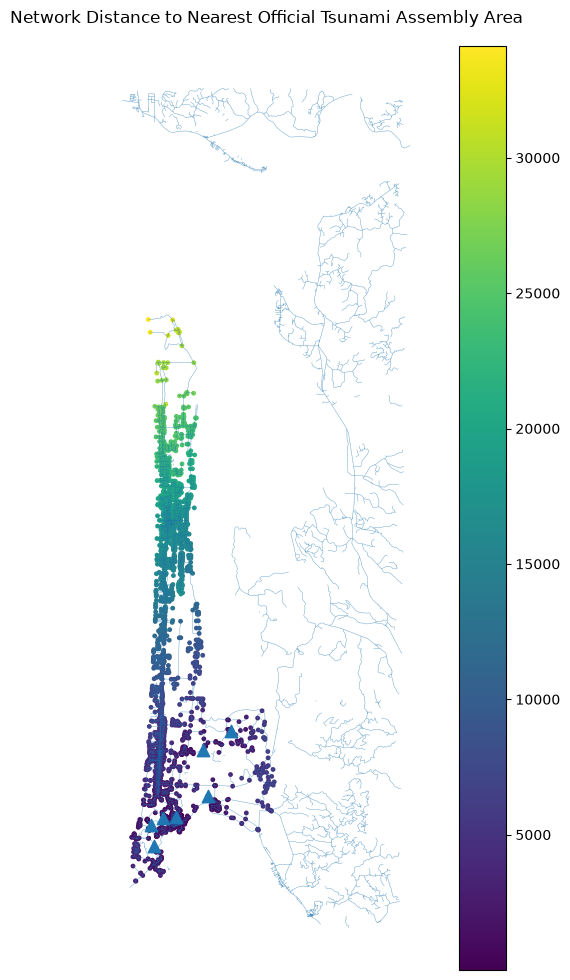

In [52]:
ax = edges_proj.plot(
    figsize=(9, 12),
    linewidth=0.3,
    alpha=0.4
)

study_nodes.plot(
    ax=ax,
    column="distance_to_destination_m",
    markersize=6,
    legend=True
)

destinations_proj.plot(
    ax=ax,
    marker="^",
    markersize=80
)

ax.set_title(
    "Network Distance to Nearest Official Tsunami Assembly Area"
)

ax.set_axis_off()

In [53]:
reachable = study_nodes["distance_to_destination_m"].notna().sum()
unreachable = study_nodes["distance_to_destination_m"].isna().sum()
total = len(study_nodes)

print(f"Reachable: {reachable} ({reachable / total:.1%})")
print(f"Unreachable: {unreachable} ({unreachable / total:.1%})")

Reachable: 3587 (96.4%)
Unreachable: 134 (3.6%)


In [54]:
study_nodes[
    "nearest_destination"
].value_counts(dropna=False)

nearest_destination
Willapa Wildlife Refuge HQ    1412
Long Beach Assembly Area      1292
School Hill                    496
North Head Rd #3               144
NaN                            134
North Head Rd #1               123
China Hill                      89
North Head Rd #2                31
Name: count, dtype: int64

## Validation with Official Evacuation Routes

In [55]:
routes_url = (
    "https://gis.dnr.wa.gov/site3/rest/services/"
    "Geology/Tsunami_Hazard/FeatureServer/20"
)

In [57]:
import requests

response = requests.get(
    routes_url,
    params={"f": "json"}
)

response.raise_for_status()

routes_metadata = response.json()

print("Layer name:", routes_metadata["name"])
print("Geometry type:", routes_metadata["geometryType"])
print("Maximum records:", routes_metadata["maxRecordCount"])

Layer name: Evacuation Routes
Geometry type: esriGeometryPolyline
Maximum records: 2000


In [58]:
route_fields = pd.DataFrame([
    {
        "name": field["name"],
        "alias": field.get("alias"),
        "type": field["type"]
    }
    for field in routes_metadata["fields"]
])

route_fields

,name,alias,type
0,OBJECTID,OBJECTID,esriFieldTypeOID
1,ROAD_NAME,Road Name,esriFieldTypeString
2,HIGHWAY_NAME,Highway Name,esriFieldTypeString
3,GLOBALID,GLOBALID,esriFieldTypeGlobalID
4,Shape__Length,SHAPE.LEN,esriFieldTypeDouble


In [59]:
routes_query_url = f"{routes_url}/query"

routes_params = {
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
    "outSR": 4326,
    "f": "geojson"
}

response = requests.get(
    routes_query_url,
    params=routes_params
)

response.raise_for_status()

routes_geojson = response.json()

print(
    "Evacuation route features downloaded:",
    len(routes_geojson["features"])
)

Evacuation route features downloaded: 876


In [60]:
routes = gpd.GeoDataFrame.from_features(
    routes_geojson["features"],
    crs="EPSG:4326"
)

routes.head()

,geometry,OBJECTID,ROAD_NAME,HIGHWAY_NAME,GLOBALID,Shape__Length
0,"LINESTRING (-122.66104 48.49529, -122.66093 48...",289,Jasper Way,NaN,{21612E76-8727-4753-B315-AFCAB57E1603},806.889947
1,"LINESTRING (-122.67025 48.4886, -122.67025 48....",290,Anaco Beach Rd,NaN,{2BE50A5A-B642-49BE-80D2-F8A72F801388},4401.033244
2,"LINESTRING (-122.68515 48.49881, -122.68382 48...",291,Sunset Ave,NaN,{AD4AF099-8149-4D3A-A554-209A11D2A64C},2126.419503
3,"LINESTRING (-122.67025 48.4886, -122.67044 48....",292,Doon Way,NaN,{019A1958-7D6B-4A2B-B91A-DD41642C2FF0},4209.587798
4,"LINESTRING (-122.67748 48.49016, -122.67761 48...",293,Unnamed road,NaN,{353990DB-8690-4C18-8C8C-9F5824C629E2},1037.613379


In [61]:
routes[
    ["ROAD_NAME", "HIGHWAY_NAME", "geometry"]
].head(20)

,ROAD_NAME,HIGHWAY_NAME,geometry
0,Jasper Way,NaN,"LINESTRING (-122.66104 48.49529, -122.66093 48..."
1,Anaco Beach Rd,NaN,"LINESTRING (-122.67025 48.4886, -122.67025 48...."
2,Sunset Ave,NaN,"LINESTRING (-122.68515 48.49881, -122.68382 48..."
3,Doon Way,NaN,"LINESTRING (-122.67025 48.4886, -122.67044 48...."
4,Unnamed road,NaN,"LINESTRING (-122.67748 48.49016, -122.67761 48..."
5,Cay Way,NaN,"LINESTRING (-122.68187 48.49592, -122.68181 48..."
6,Kingsway,NaN,"LINESTRING (-122.68181 48.49662, -122.68203 48..."
7,Kingsway,NaN,"LINESTRING (-122.67025 48.49036, -122.66943 48..."
8,Higgins Airport Way,NaN,"LINESTRING (-122.4132 48.45042, -122.41332 48...."
9,Cains Ct,NaN,"LINESTRING (-122.44385 48.56119, -122.44377 48..."


In [63]:
study_geom = peninsula.geometry.union_all()

long_beach_routes = routes[
    routes.geometry.intersects(study_geom)
].copy()

print(
    "Evacuation route features in study area:",
    len(long_beach_routes)
)

Evacuation route features in study area: 115


In [64]:
long_beach_routes[
    ["ROAD_NAME", "HIGHWAY_NAME"]
].drop_duplicates()

,ROAD_NAME,HIGHWAY_NAME
118,Stackpole Rd,State Highway 103
183,NaN,State Route 101
184,Pacific Way,State Highway 101
185,China Hill Ln,NaN
186,unnamed road,NaN
...,...,...
815,180th Pl,NaN
816,168th Ln,NaN
817,Birch St,NaN
818,unnamed trail,NaN


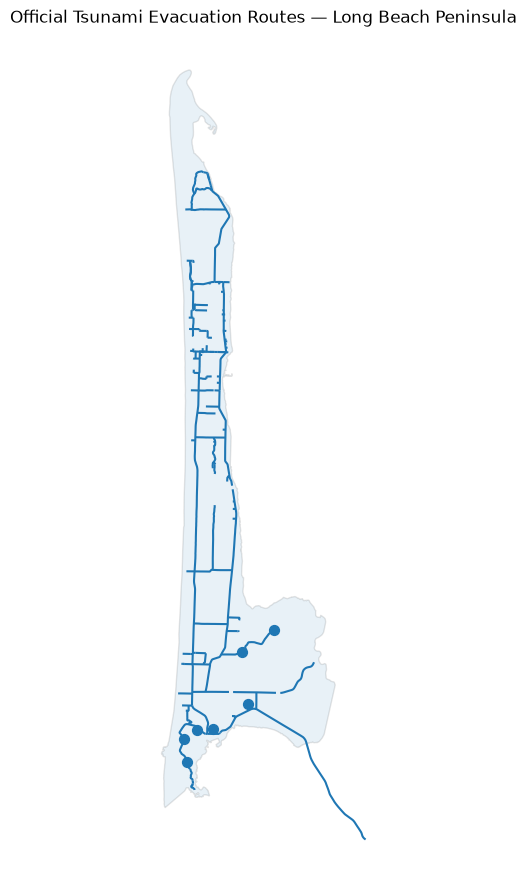

In [66]:
ax = peninsula.plot(
    figsize=(8, 11),
    edgecolor="black",
    alpha=0.1
)

long_beach_routes.plot(
    ax=ax,
    linewidth=1.5
)

destinations.plot(
    ax=ax,
    marker="o",
    markersize=50
)

ax.set_title(
    "Official Tsunami Evacuation Routes — Long Beach Peninsula"
)

ax.set_axis_off()

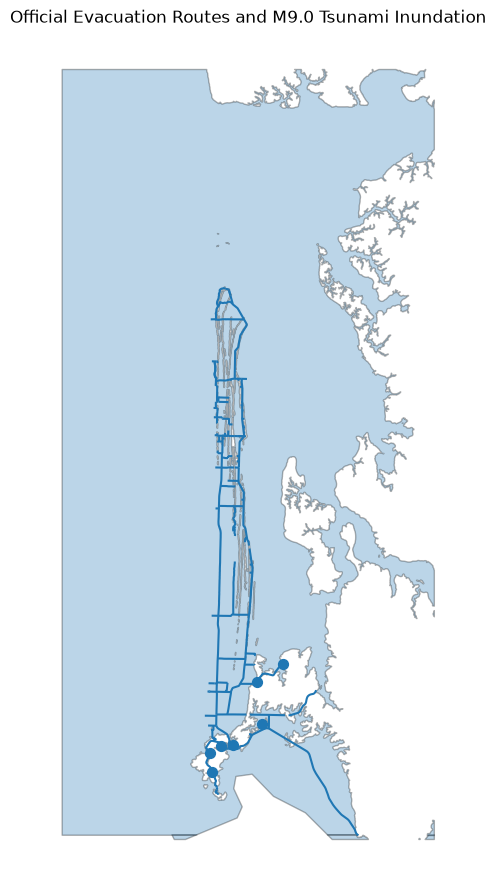

In [67]:
ax = hazard.plot(
    figsize=(8, 11),
    edgecolor="black",
    alpha=0.3
)

long_beach_routes.plot(
    ax=ax,
    linewidth=1.5
)

destinations.plot(
    ax=ax,
    marker="o",
    markersize=50
)

ax.set_title(
    "Official Evacuation Routes and M9.0 Tsunami Inundation"
)

ax.set_axis_off()

In [68]:
hazard_geom = hazard.geometry.union_all()
hazard_boundary = hazard_geom.boundary

In [69]:
route_crossings = []

for idx, row in long_beach_routes.iterrows():

    crossing = row.geometry.intersection(
        hazard_boundary
    )

    if not crossing.is_empty:
        route_crossings.append({
            "route_index": idx,
            "ROAD_NAME": row["ROAD_NAME"],
            "HIGHWAY_NAME": row["HIGHWAY_NAME"],
            "geometry": crossing
        })

In [70]:
route_crossings = gpd.GeoDataFrame(
    route_crossings,
    crs="EPSG:4326"
)

route_crossings

,route_index,ROAD_NAME,HIGHWAY_NAME,geometry
0,118,Stackpole Rd,State Highway 103,"MULTIPOINT ((-124.04567 46.60748), (-124.0312 ..."
1,183,NaN,State Route 101,POINT (-124.03364 46.30941)
2,185,China Hill Ln,NaN,POINT (-124.01055 46.32249)
3,186,unnamed road,NaN,POINT (-124.02192 46.31767)
4,187,NaN,State Highway 101,POINT (-124.02268 46.3311)
...,...,...,...,...
63,815,180th Pl,NaN,POINT (-124.0233 46.43247)
64,816,168th Ln,NaN,"MULTIPOINT ((-124.02352 46.42329), (-124.02144..."
65,818,unnamed trail,NaN,"MULTIPOINT ((-124.05154 46.59892), (-124.05236..."
66,819,Oysterville Rd,State Highway 103,"MULTIPOINT ((-124.03771 46.54919), (-124.03707..."


In [71]:
route_crossings.geometry.geom_type.value_counts()

Point         40
MultiPoint    28
Name: count, dtype: int64

In [72]:
crossing_points = route_crossings.explode(
    index_parts=False
).reset_index(drop=True)

print("Crossing points:", len(crossing_points))

crossing_points.geometry.geom_type.value_counts()

Crossing points: 167


Point    167
Name: count, dtype: int64

In [73]:
crossing_points[
    ["ROAD_NAME", "HIGHWAY_NAME", "geometry"]
].head(20)

,ROAD_NAME,HIGHWAY_NAME,geometry
0,Stackpole Rd,State Highway 103,POINT (-124.04567 46.60748)
1,Stackpole Rd,State Highway 103,POINT (-124.0312 46.57872)
2,Stackpole Rd,State Highway 103,POINT (-124.04307 46.60664)
3,Stackpole Rd,State Highway 103,POINT (-124.03455 46.56955)
4,Stackpole Rd,State Highway 103,POINT (-124.02652 46.58384)
5,Stackpole Rd,State Highway 103,POINT (-124.04152 46.6027)
6,Stackpole Rd,State Highway 103,POINT (-124.0418 46.60339)
7,Stackpole Rd,State Highway 103,POINT (-124.04181 46.60338)
8,Stackpole Rd,State Highway 103,POINT (-124.03739 46.56259)
9,Stackpole Rd,State Highway 103,POINT (-124.03329 46.57418)


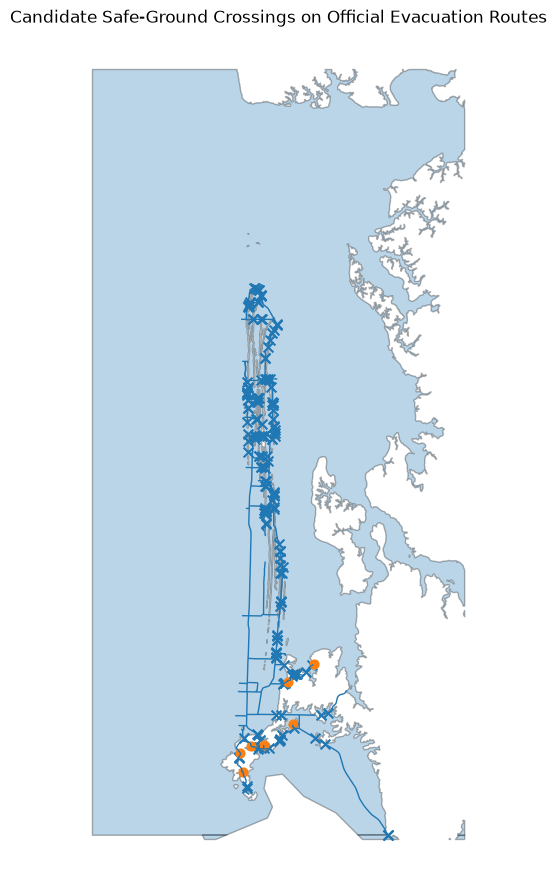

In [74]:
ax = hazard.plot(
    figsize=(8, 11),
    edgecolor="black",
    alpha=0.3
)

long_beach_routes.plot(
    ax=ax,
    linewidth=1
)

crossing_points.plot(
    ax=ax,
    marker="x",
    markersize=50
)

destinations.plot(
    ax=ax,
    marker="o",
    markersize=40
)

ax.set_title(
    "Candidate Safe-Ground Crossings on Official Evacuation Routes"
)

ax.set_axis_off()

In [75]:
crossing_points["geometry_wkt"] = (
    crossing_points.geometry.to_wkt()
)

print(
    "Exact duplicate crossings:",
    crossing_points["geometry_wkt"].duplicated().sum()
)

Exact duplicate crossings: 0


In [77]:
crossing_points_unique = (
    crossing_points
    .drop_duplicates(subset="geometry_wkt")
    .drop(columns="geometry_wkt")
    .copy()
)

print(
    "Unique exact crossing points:",
    len(crossing_points_unique)
)

Unique exact crossing points: 167


In [78]:
print("Raw crossing features:", len(route_crossings))
print("Exploded crossing points:", len(crossing_points))
print(
    "Unique exact crossing points:",
    len(crossing_points_unique)
)

Raw crossing features: 68
Exploded crossing points: 167
Unique exact crossing points: 167


In [79]:
crossings_proj = crossing_points_unique.to_crs(
    G_proj.graph["crs"]
)

routes_proj = long_beach_routes.to_crs(
    G_proj.graph["crs"]
)

hazard_proj = hazard.to_crs(
    G_proj.graph["crs"]
)

hazard_geom_proj = hazard_proj.geometry.union_all()

In [80]:
crossing_validation = []

for idx, crossing in crossings_proj.iterrows():

    route_idx = crossing["route_index"]

    route_geom = routes_proj.loc[route_idx].geometry
    point = crossing.geometry

    local_route = route_geom.intersection(
        point.buffer(20)
    )

    inside_length = (
        local_route
        .intersection(hazard_geom_proj)
        .length
    )

    outside_length = (
        local_route
        .difference(hazard_geom_proj)
        .length
    )

    crossing_validation.append({
        "inside_length_m": inside_length,
        "outside_length_m": outside_length,
        "is_true_crossing": (
            inside_length > 1
            and outside_length > 1
        )
    })

In [81]:
validation_df = pd.DataFrame(
    crossing_validation,
    index=crossings_proj.index
)

crossings_proj = pd.concat(
    [crossings_proj, validation_df],
    axis=1
)

In [82]:
crossings_proj["is_true_crossing"].value_counts()

is_true_crossing
True    167
Name: count, dtype: int64

In [83]:
crossings_proj[
    ~crossings_proj["is_true_crossing"]
][
    [
        "ROAD_NAME",
        "inside_length_m",
        "outside_length_m"
    ]
].head(20)

,ROAD_NAME,inside_length_m,outside_length_m


In [84]:
valid_crossings = crossings_proj[
    crossings_proj["is_true_crossing"]
].copy()

print(
    "Validated hazard-exit crossings:",
    len(valid_crossings)
)

Validated hazard-exit crossings: 167


In [85]:
nearest_crossing_edges, crossing_edge_distances = (
    ox.distance.nearest_edges(
        G_proj,
        X=valid_crossings.geometry.x,
        Y=valid_crossings.geometry.y,
        return_dist=True
    )
)

In [86]:
valid_crossings["nearest_edge"] = list(
    nearest_crossing_edges
)

valid_crossings["edge_distance_m"] = (
    crossing_edge_distances
)

In [87]:
valid_crossings[
    "edge_distance_m"
].describe()

count    167.000000
mean       5.145380
std       15.989476
min        0.000072
25%        0.569360
50%        1.143621
75%        2.952259
max      139.754575
Name: edge_distance_m, dtype: float64

In [88]:
valid_crossings.sort_values(
    "edge_distance_m",
    ascending=False
)[
    [
        "ROAD_NAME",
        "HIGHWAY_NAME",
        "edge_distance_m"
    ]
].head(20)

,ROAD_NAME,HIGHWAY_NAME,edge_distance_m
147,174th Ln,NaN,139.754575
80,Dune Forest Loop Trail,NaN,99.584665
148,180th Pl,NaN,72.058394
78,Dune Forest Loop Trail,NaN,65.925733
77,Dune Forest Loop Trail,NaN,43.736113
152,unnamed trail,NaN,37.834259
116,Pacific Pines State Park roadway,NaN,31.357500
107,private drive,NaN,30.238742
154,unnamed trail,NaN,28.231743
151,unnamed trail,NaN,19.310322


In [89]:
from shapely.ops import nearest_points

In [90]:
network_access_points = []

for idx, crossing in valid_crossings.iterrows():

    u, v, key = crossing["nearest_edge"]

    edge_geom = get_edge_geometry(
        G_proj,
        u,
        v,
        key
    )

    _, access_point = nearest_points(
        crossing.geometry,
        edge_geom
    )

    network_access_points.append(
        access_point
    )

In [91]:
valid_crossings["access_geometry"] = (
    network_access_points
)

valid_crossings["access_distance_m"] = [
    row.geometry.distance(row["access_geometry"])
    for _, row in valid_crossings.iterrows()
]

In [92]:
difference = (
    valid_crossings["edge_distance_m"]
    - valid_crossings["access_distance_m"]
).abs()

print(
    "Maximum distance calculation difference:",
    difference.max()
)

Maximum distance calculation difference: 4.2751091555714993e-10


In [93]:
valid_crossings["edge_id"] = (
    valid_crossings["nearest_edge"]
    .astype(str)
)

print(
    "Validated crossings:",
    len(valid_crossings)
)

print(
    "Unique nearest network edges:",
    valid_crossings["edge_id"].nunique()
)

Validated crossings: 167
Unique nearest network edges: 123


In [94]:
poor_alignment = valid_crossings[
    valid_crossings["edge_distance_m"] > 20
].copy()

print("Crossings more than 20 m from OSM network:", len(poor_alignment))

poor_alignment[
    [
        "ROAD_NAME",
        "HIGHWAY_NAME",
        "edge_distance_m"
    ]
].sort_values(
    "edge_distance_m",
    ascending=False
)

Crossings more than 20 m from OSM network: 9


,ROAD_NAME,HIGHWAY_NAME,edge_distance_m
147,174th Ln,NaN,139.754575
80,Dune Forest Loop Trail,NaN,99.584665
148,180th Pl,NaN,72.058394
78,Dune Forest Loop Trail,NaN,65.925733
77,Dune Forest Loop Trail,NaN,43.736113
152,unnamed trail,NaN,37.834259
116,Pacific Pines State Park roadway,NaN,31.357500
107,private drive,NaN,30.238742
154,unnamed trail,NaN,28.231743


In [95]:
print(
    "Share within 20 m:",
    f"{(valid_crossings['edge_distance_m'] <= 20).mean():.1%}"
)

Share within 20 m: 94.6%


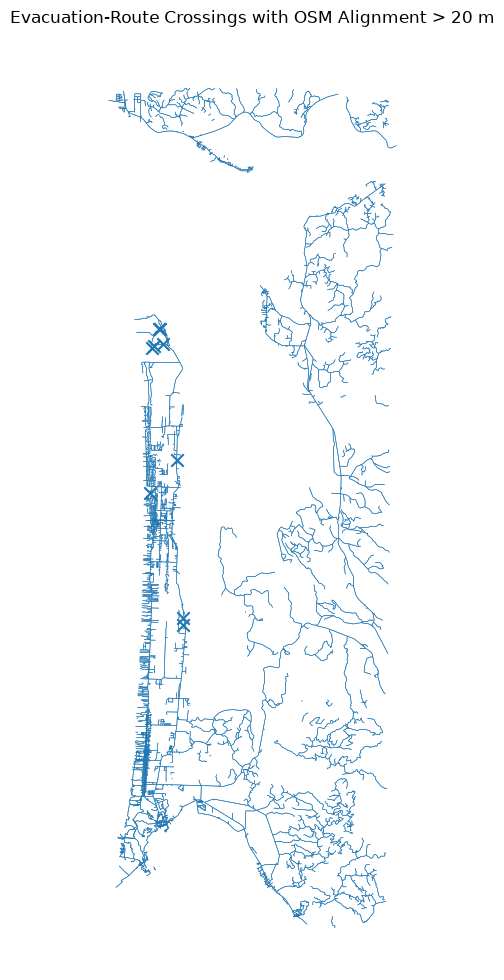

In [96]:
ax = edges_proj.plot(
    figsize=(9, 12),
    linewidth=0.4
)

poor_alignment.plot(
    ax=ax,
    marker="x",
    markersize=80
)

ax.set_title(
    "Evacuation-Route Crossings with OSM Alignment > 20 m"
)

ax.set_axis_off()

In [97]:
access_points_gdf = gpd.GeoDataFrame(
    valid_crossings.copy(),
    geometry=valid_crossings["access_geometry"],
    crs=valid_crossings.crs
)

In [98]:
dedup_distance_m = 10

proximity_graph = nx.Graph()

proximity_graph.add_nodes_from(
    access_points_gdf.index
)

for i, point_i in access_points_gdf.geometry.items():

    distances = access_points_gdf.geometry.distance(
        point_i
    )

    nearby = distances[
        (distances <= dedup_distance_m)
        & (distances > 0)
    ].index

    for j in nearby:
        proximity_graph.add_edge(i, j)

In [99]:
crossing_clusters = list(
    nx.connected_components(proximity_graph)
)

print("Raw validated crossings:", len(valid_crossings))
print(
    "Crossing clusters within 10 m:",
    len(crossing_clusters)
)

Raw validated crossings: 167
Crossing clusters within 10 m: 158


In [100]:
representative_indices = []

for cluster in crossing_clusters:

    cluster_rows = valid_crossings.loc[list(cluster)]

    representative_idx = (
        cluster_rows["edge_distance_m"]
        .idxmin()
    )

    representative_indices.append(
        representative_idx
    )

In [101]:
safe_exits = valid_crossings.loc[
    representative_indices
].copy()

safe_exits = safe_exits.reset_index(drop=True)

print(
    "Final candidate safe exits after 10 m deduplication:",
    len(safe_exits)
)

Final candidate safe exits after 10 m deduplication: 158


In [102]:
safe_exits["edge_distance_m"].describe()

count    158.000000
mean       5.312421
std       16.418506
min        0.000072
25%        0.536758
50%        1.143595
75%        2.860493
max      139.754575
Name: edge_distance_m, dtype: float64

In [103]:
def count_spatial_clusters(gdf, tolerance_m):

    G = nx.Graph()
    G.add_nodes_from(gdf.index)

    for i, point_i in gdf.geometry.items():

        distances = gdf.geometry.distance(point_i)

        nearby = distances[
            (distances <= tolerance_m)
            & (distances > 0)
        ].index

        for j in nearby:
            G.add_edge(i, j)

    return nx.number_connected_components(G)

In [104]:
for tolerance in [5, 10, 20, 30, 50]:
    print(
        f"{tolerance:>2} m:",
        count_spatial_clusters(
            access_points_gdf,
            tolerance
        )
    )

 5 m: 161
10 m: 158
20 m: 156
30 m: 153
50 m: 139


In [105]:
dedup_distance_m = 20

proximity_graph = nx.Graph()
proximity_graph.add_nodes_from(access_points_gdf.index)

for i, point_i in access_points_gdf.geometry.items():

    distances = access_points_gdf.geometry.distance(point_i)

    nearby = distances[
        (distances <= dedup_distance_m)
        & (distances > 0)
    ].index

    for j in nearby:
        proximity_graph.add_edge(i, j)

crossing_clusters = list(
    nx.connected_components(proximity_graph)
)

print("Validated crossings:", len(valid_crossings))
print("20 m crossing clusters:", len(crossing_clusters))

Validated crossings: 167
20 m crossing clusters: 156


In [106]:
representative_indices = []

for cluster in crossing_clusters:

    cluster_rows = valid_crossings.loc[list(cluster)]

    representative_idx = (
        cluster_rows["edge_distance_m"]
        .idxmin()
    )

    representative_indices.append(
        representative_idx
    )

safe_exits = valid_crossings.loc[
    representative_indices
].copy()

safe_exits = safe_exits.reset_index(drop=True)

print("Final safe-exit candidates:", len(safe_exits))

Final safe-exit candidates: 156


In [107]:
poor_alignment = safe_exits[
    safe_exits["edge_distance_m"] > 20
].copy()

print(
    "Safe exits more than 20 m from OSM network:",
    len(poor_alignment)
)

Safe exits more than 20 m from OSM network: 9


In [108]:
poor_alignment[
    [
        "ROAD_NAME",
        "HIGHWAY_NAME",
        "edge_distance_m"
    ]
].sort_values(
    "edge_distance_m",
    ascending=False
)

,ROAD_NAME,HIGHWAY_NAME,edge_distance_m
136,174th Ln,NaN,139.754575
70,Dune Forest Loop Trail,NaN,99.584665
137,180th Pl,NaN,72.058394
68,Dune Forest Loop Trail,NaN,65.925733
67,Dune Forest Loop Trail,NaN,43.736113
141,unnamed trail,NaN,37.834259
106,Pacific Pines State Park roadway,NaN,31.357500
97,private drive,NaN,30.238742
143,unnamed trail,NaN,28.231743


In [109]:
print(
    "Safe exits within 20 m of OSM:",
    f"{(safe_exits['edge_distance_m'] <= 20).mean():.1%}"
)

Safe exits within 20 m of OSM: 94.2%


In [110]:
safe_exit_access = gpd.GeoDataFrame(
    safe_exits.copy(),
    geometry=safe_exits["access_geometry"],
    crs=safe_exits.crs
)

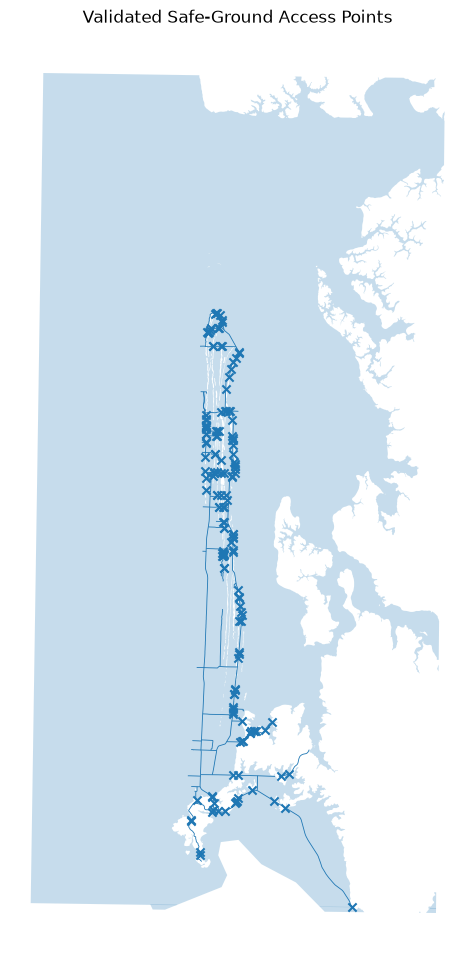

In [111]:
ax = hazard_proj.plot(
    figsize=(9, 12),
    alpha=0.25
)

routes_proj.plot(
    ax=ax,
    linewidth=0.6
)

safe_exit_access.plot(
    ax=ax,
    marker="x",
    markersize=35
)

ax.set_title(
    "Validated Safe-Ground Access Points"
)

ax.set_axis_off()

In [112]:
G_safe = G_proj.copy()

safe_sink = "__safe_ground__"

G_safe.add_node(safe_sink)

safe_terminal_nodes = []

In [113]:
for idx, exit_row in safe_exits.iterrows():

    u, v, key = exit_row["nearest_edge"]

    access_point = exit_row["access_geometry"]
    off_network_distance = exit_row["access_distance_m"]

    terminal = f"safe_exit_{idx}"

    safe_terminal_nodes.append(terminal)

    G_safe.add_node(
        terminal,
        exit_id=idx
    )

    # Approach from u
    u_to_access = distance_from_start_node(
        G_safe,
        u,
        v,
        key,
        access_point
    )

    G_safe.add_edge(
        u,
        terminal,
        length=u_to_access + off_network_distance
    )

    # Approach from v if reverse travel exists
    reverse_edges = G_safe.get_edge_data(v, u)

    if reverse_edges is not None:

        best_reverse_key = min(
            reverse_edges,
            key=lambda k: get_edge_geometry(
                G_safe,
                v,
                u,
                k
            ).distance(access_point)
        )

        v_to_access = distance_from_start_node(
            G_safe,
            v,
            u,
            best_reverse_key,
            access_point
        )

        G_safe.add_edge(
            v,
            terminal,
            length=v_to_access + off_network_distance
        )

    G_safe.add_edge(
        terminal,
        safe_sink,
        length=0.0
    )

In [114]:
G_safe_reverse = G_safe.reverse(copy=False)

safe_distances, safe_paths = nx.single_source_dijkstra(
    G_safe_reverse,
    source=safe_sink,
    weight="length"
)

In [115]:
nodes_proj["distance_to_safe_ground_m"] = [
    safe_distances.get(node, np.nan)
    for node in nodes_proj.index
]

In [116]:
study_nodes_safe = nodes_proj[
    nodes_proj["in_study_area"]
].copy()

In [117]:
safe_reachable = (
    study_nodes_safe["distance_to_safe_ground_m"]
    .notna()
    .sum()
)

safe_unreachable = (
    study_nodes_safe["distance_to_safe_ground_m"]
    .isna()
    .sum()
)

total = len(study_nodes_safe)

print("Study-area nodes:", total)

print(
    "Reachable:",
    safe_reachable,
    f"({safe_reachable / total:.1%})"
)

print(
    "Unreachable:",
    safe_unreachable,
    f"({safe_unreachable / total:.1%})"
)

Study-area nodes: 3721
Reachable: 3587 (96.4%)
Unreachable: 134 (3.6%)


In [118]:
study_nodes_safe[
    "distance_to_safe_ground_m"
].describe()

count    3587.000000
mean     1752.988772
std      1415.408309
min         1.029719
25%       509.114984
50%      1326.456550
75%      3005.579345
max      6840.691417
Name: distance_to_safe_ground_m, dtype: float64

In [119]:
study_nodes_safe[
    [
        "distance_to_destination_m",
        "distance_to_safe_ground_m"
    ]
].describe()

,distance_to_destination_m,distance_to_safe_ground_m
count,3587.000000,3587.000000
mean,9690.010884,1752.988772
std,7988.401830,1415.408309
min,2.071309,1.029719
25%,3349.086154,509.114984
50%,5313.619629,1326.456550
75%,17440.271141,3005.579345
max,34126.647407,6840.691417


In [120]:
#distance_to_destination_m
#= distance to formal post-tsunami assembly area

#distance_to_safe_ground_m
#= distance to nearest modeled safe-ground exit

In [121]:
comparison = pd.DataFrame({
    "Assembly area model": study_nodes_safe[
        "distance_to_destination_m"
    ].describe(),
    
    "Safe-ground model": study_nodes_safe[
        "distance_to_safe_ground_m"
    ].describe()
})

comparison

,Assembly area model,Safe-ground model
count,3587.000000,3587.000000
mean,9690.010884,1752.988772
std,7988.401830,1415.408309
min,2.071309,1.029719
25%,3349.086154,509.114984
50%,5313.619629,1326.456550
75%,17440.271141,3005.579345
max,34126.647407,6840.691417


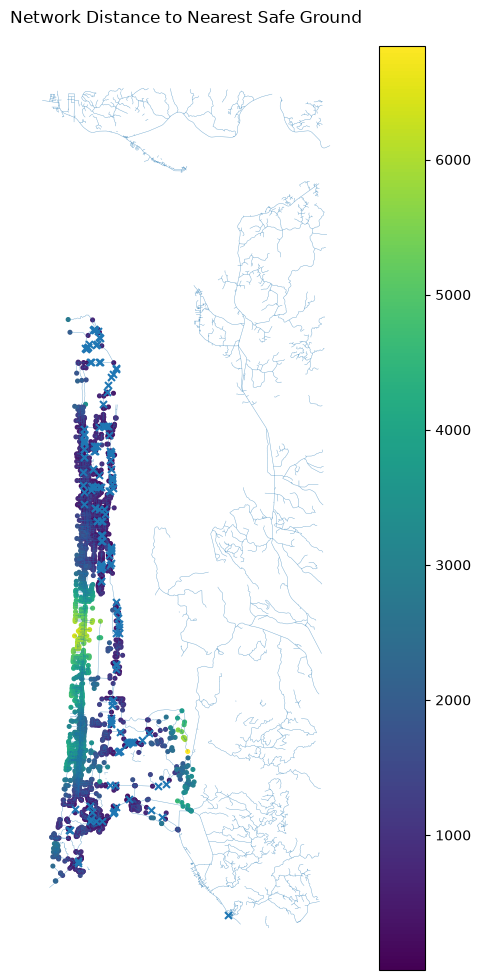

In [122]:
ax = edges_proj.plot(
    figsize=(9, 12),
    linewidth=0.3,
    alpha=0.35
)

study_nodes_safe.plot(
    ax=ax,
    column="distance_to_safe_ground_m",
    markersize=7,
    legend=True
)

safe_exit_access.plot(
    ax=ax,
    marker="x",
    markersize=25
)

ax.set_title(
    "Network Distance to Nearest Safe Ground"
)

ax.set_axis_off()

In [123]:
unreachable_nodes = study_nodes_safe[
    study_nodes_safe["distance_to_safe_ground_m"].isna()
].copy()

print("Unreachable nodes:", len(unreachable_nodes))

Unreachable nodes: 134


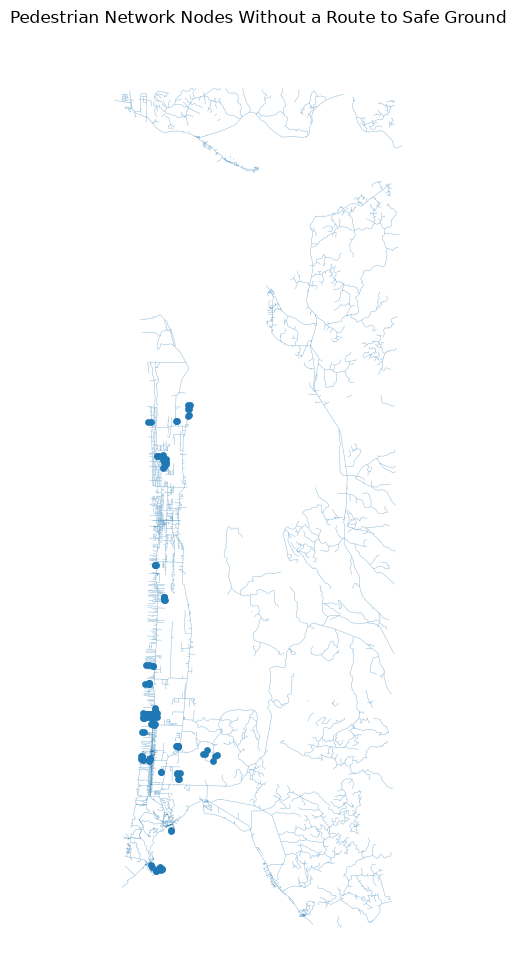

In [124]:
ax = edges_proj.plot(
    figsize=(9, 12),
    linewidth=0.3,
    alpha=0.3
)

unreachable_nodes.plot(
    ax=ax,
    markersize=15
)

ax.set_title(
    "Pedestrian Network Nodes Without a Route to Safe Ground"
)

ax.set_axis_off()

In [125]:
components_proj = sorted(
    nx.weakly_connected_components(G_proj),
    key=len,
    reverse=True
)

node_to_component = {
    node: component_id
    for component_id, component in enumerate(components_proj)
    for node in component
}

unreachable_nodes["component_id"] = [
    node_to_component[node]
    for node in unreachable_nodes.index
]

unreachable_nodes["component_id"].value_counts().head(20)

component_id
6     8
7     8
8     6
9     6
11    6
12    4
14    4
15    4
17    4
18    4
20    4
21    4
22    4
27    2
28    2
34    2
35    2
36    2
42    2
43    2
Name: count, dtype: int64

In [126]:
print(
    "Unreachable nodes in largest component:",
    (unreachable_nodes["component_id"] == 0).sum()
)

Unreachable nodes in largest component: 0


In [127]:
component_sizes = {
    component_id: len(component)
    for component_id, component in enumerate(components_proj)
}

unreachable_summary = (
    unreachable_nodes
    .groupby("component_id")
    .size()
    .rename("unreachable_nodes")
    .to_frame()
)

unreachable_summary["component_total_nodes"] = (
    unreachable_summary.index.map(component_sizes)
)

unreachable_summary["share_unreachable"] = (
    unreachable_summary["unreachable_nodes"]
    / unreachable_summary["component_total_nodes"]
)

unreachable_summary.sort_values(
    "unreachable_nodes",
    ascending=False
).head(20)

,unreachable_nodes,component_total_nodes,share_unreachable
component_id,,,
6,8,8,1.0
7,8,8,1.0
8,6,6,1.0
9,6,6,1.0
11,6,6,1.0
18,4,4,1.0
22,4,4,1.0
21,4,4,1.0
20,4,4,1.0


In [128]:
print(
    "Disconnected components containing unreachable nodes:",
    unreachable_nodes["component_id"].nunique()
)

Disconnected components containing unreachable nodes: 48


In [129]:
print("Total unreachable nodes:", len(unreachable_nodes))
print(
    "Largest unreachable cluster:",
    unreachable_nodes["component_id"]
    .value_counts()
    .max()
)

Total unreachable nodes: 134
Largest unreachable cluster: 8


In [130]:
nodes_proj["component_id"] = [
    node_to_component[node]
    for node in nodes_proj.index
]

study_nodes_safe = nodes_proj[
    nodes_proj["in_study_area"]
].copy()

In [131]:
component_diagnostic = (
    study_nodes_safe
    .groupby("component_id")
    .agg(
        total_nodes=("geometry", "size"),
        reachable_nodes=(
            "distance_to_safe_ground_m",
            lambda x: x.notna().sum()
        )
    )
)

component_diagnostic["unreachable_nodes"] = (
    component_diagnostic["total_nodes"]
    - component_diagnostic["reachable_nodes"]
)

component_diagnostic["reachable_share"] = (
    component_diagnostic["reachable_nodes"]
    / component_diagnostic["total_nodes"]
)

component_diagnostic.sort_values(
    "total_nodes",
    ascending=False
).head(15)

,total_nodes,reachable_nodes,unreachable_nodes,reachable_share
component_id,,,,
0,3587,3587,0,1.0
7,8,0,8,0.0
6,8,0,8,0.0
8,6,0,6,0.0
9,6,0,6,0.0
11,6,0,6,0.0
20,4,0,4,0.0
22,4,0,4,0.0
21,4,0,4,0.0


In [132]:
analysis_nodes = study_nodes_safe[
    study_nodes_safe["distance_to_safe_ground_m"].notna()
].copy()

excluded_nodes = study_nodes_safe[
    study_nodes_safe["distance_to_safe_ground_m"].isna()
].copy()

print("Study-area nodes:", len(study_nodes_safe))
print("Analysis nodes:", len(analysis_nodes))
print("Disconnected nodes excluded:", len(excluded_nodes))
print(
    "Analysis-network share:",
    f"{len(analysis_nodes) / len(study_nodes_safe):.1%}"
)

Study-area nodes: 3721
Analysis nodes: 3587
Disconnected nodes excluded: 134
Analysis-network share: 96.4%


In [133]:
safe_ground_summary = (
    analysis_nodes["distance_to_safe_ground_m"]
    .describe()
)

safe_ground_summary

count    3587.000000
mean     1752.988772
std      1415.408309
min         1.029719
25%       509.114984
50%      1326.456550
75%      3005.579345
max      6840.691417
Name: distance_to_safe_ground_m, dtype: float64

In [134]:
analysis_nodes["distance_to_safe_ground_km"] = (
    analysis_nodes["distance_to_safe_ground_m"] / 1000
)

analysis_nodes[
    "distance_to_safe_ground_km"
].describe()

count    3587.000000
mean        1.752989
std         1.415408
min         0.001030
25%         0.509115
50%         1.326457
75%         3.005579
max         6.840691
Name: distance_to_safe_ground_km, dtype: float64

### Network connectivity QA

Of 3,721 pedestrian-network nodes within the Long Beach Peninsula study area, 3,587 (96.4%) were connected to at least one modeled safe-ground access point. The remaining 134 nodes belonged exclusively to disconnected OpenStreetMap network components; none were located in the largest connected component. These disconnected fragments were retained for quality-control reporting but excluded from primary network-distance calculations.

In [135]:
unreachable_component_ids = set(
    excluded_nodes["component_id"]
)

excluded_edges = edges_proj[
    edges_proj.index.get_level_values("u").map(
        node_to_component
    ).isin(unreachable_component_ids)
].copy()

In [136]:
excluded_edges["highway"].astype(str).value_counts().head(15)

highway
service                84
path                   60
footway                16
track                  14
unclassified            6
residential             6
['path', 'service']     2
Name: count, dtype: int64

In [137]:
safe_exit_path = (
    processed_dir / "long_beach_safe_ground_access.geojson"
)

safe_exit_access[
    [
        "ROAD_NAME",
        "HIGHWAY_NAME",
        "edge_distance_m",
        "geometry"
    ]
].to_json()

'{"type": "FeatureCollection", "features": [{"id": "0", "type": "Feature", "properties": {"ROAD_NAME": "Stackpole Rd", "HIGHWAY_NAME": "State Highway 103", "edge_distance_m": 3.35308299115929}, "geometry": {"type": "Point", "coordinates": [419921.6612319387, 5162081.160718425]}}, {"id": "1", "type": "Feature", "properties": {"ROAD_NAME": "Stackpole Rd", "HIGHWAY_NAME": "State Highway 103", "edge_distance_m": 7.57638011162597}, "geometry": {"type": "Point", "coordinates": [420982.1567375456, 5158871.332909012]}}, {"id": "2", "type": "Feature", "properties": {"ROAD_NAME": "Stackpole Rd", "HIGHWAY_NAME": "State Highway 103", "edge_distance_m": 0.3826114189827059}, "geometry": {"type": "Point", "coordinates": [420120.864053487, 5161981.033049599]}}, {"id": "3", "type": "Feature", "properties": {"ROAD_NAME": "Stackpole Rd", "HIGHWAY_NAME": "State Highway 103", "edge_distance_m": 10.387315883239564}, "geometry": {"type": "Point", "coordinates": [420721.51475969475, 5157861.419523908]}}, {"id

In [138]:
safe_exit_path.write_text(
    safe_exit_access[
        [
            "ROAD_NAME",
            "HIGHWAY_NAME",
            "edge_distance_m",
            "geometry"
        ]
    ].to_json(),
    encoding="utf-8"
)

print(f"Saved safe-ground access points to: {safe_exit_path}")

Saved safe-ground access points to: /Users/zml/Desktop/Projects/tsunami-evacuation-resilience/data/processed/long_beach_safe_ground_access.geojson


In [139]:
safe_exit_path.exists()

True